In [2]:
!pip install undetected-chromedriver pandas matplotlib seaborn beautifulsoup4

In [3]:
import undetected_chromedriver as uc
import pandas as pd
from bs4 import BeautifulSoup, Comment
import matplotlib.pyplot as plt
import seaborn as sns
import time
import io
import warnings

warnings.filterwarnings('ignore')
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [4]:
options = uc.ChromeOptions()
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')

# Forzamos la versión correcta para tu Chrome 145
driver = uc.Chrome(options=options, version_main=145)
print('✅ Navegador listo — se abrirá una ventana de Chrome, es normal')

✅ Navegador listo — se abrirá una ventana de Chrome, es normal


In [5]:
URL_JUGADORES = 'https://fbref.com/en/squads/632f1838/2025-2026/Cruz-Azul-Stats'

driver.get(URL_JUGADORES)
print('⏳ Esperando Cloudflare... (15 segundos)')
time.sleep(15)

html = driver.page_source
soup = BeautifulSoup(html, 'html.parser')

# Recolectar todas las tablas
tablas_html = []
for tabla in soup.find_all('table'):
    tablas_html.append(str(tabla))
for comentario in soup.find_all(string=lambda t: isinstance(t, Comment)):
    if '<table' in str(comentario):
        soup_inner = BeautifulSoup(str(comentario), 'html.parser')
        for tabla in soup_inner.find_all('table'):
            tablas_html.append(str(tabla))

# Tabla 9 = estadísticas de jugadores
df_jugadores = pd.read_html(io.StringIO(tablas_html[9]))[0]

# Tabla 10 = partidos
df_partidos = pd.read_html(io.StringIO(tablas_html[10]))[0]

# Aplanar columnas multi-nivel
if isinstance(df_jugadores.columns, pd.MultiIndex):
    df_jugadores.columns = ['_'.join(col).strip('_') for col in df_jugadores.columns]
if isinstance(df_partidos.columns, pd.MultiIndex):
    df_partidos.columns = ['_'.join(col).strip('_') for col in df_partidos.columns]

# Limpiar fila de totales
df_jugadores = df_jugadores[df_jugadores['Unnamed: 0_level_0_Player'] != 'Squad Total'].reset_index(drop=True)
df_partidos  = df_partidos.dropna(subset=['Date']).reset_index(drop=True)

print(f'✅ {len(df_jugadores)} jugadores encontrados')
print(f'✅ {len(df_partidos)} partidos encontrados')
print(f'\nColumnas jugadores: {list(df_jugadores.columns)}')
print(f'\nColumnas partidos: {list(df_partidos.columns)}')
df_jugadores.head()

⏳ Esperando Cloudflare... (15 segundos)
✅ 39 jugadores encontrados
✅ 39 partidos encontrados

Columnas jugadores: ['Unnamed: 0_level_0_Player', 'Unnamed: 1_level_0_Nation', 'Unnamed: 2_level_0_Pos', 'Unnamed: 3_level_0_Age', 'Unnamed: 4_level_0_MP', 'Playing Time_Starts', 'Playing Time_Min', 'Playing Time_90s', 'Performance_Gls', 'Performance_Ast', 'Performance_G+A', 'Performance_G-PK', 'Performance_PK', 'Performance_PKatt', 'Performance_CrdY', 'Performance_CrdR', 'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Per 90 Minutes_G+A', 'Per 90 Minutes_G-PK', 'Per 90 Minutes_G+A-PK', 'Unnamed: 21_level_0_Matches']

Columnas partidos: ['Date', 'Time', 'Comp', 'Round', 'Day', 'Venue', 'Result', 'GF', 'GA', 'Opponent', 'Poss', 'Attendance', 'Captain', 'Formation', 'Opp Formation', 'Referee', 'Match Report', 'Notes']


,Unnamed: 0_level_0_Player,Unnamed: 1_level_0_Nation,Unnamed: 2_level_0_Pos,Unnamed: 3_level_0_Age,Unnamed: 4_level_0_MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,Performance_Gls,Performance_Ast,...,Performance_PK,Performance_PKatt,Performance_CrdY,Performance_CrdR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Unnamed: 21_level_0_Matches
0,José Paradela,ar ARG,"MF,FW",27-086,27,27,2063,22.9,8,6,...,0,1,3,0,0.35,0.26,0.61,0.35,0.61,Matches
1,Willer Ditta,co COL,DF,29-047,27,26,2362,26.2,0,0,...,0,0,8,0,0.00,0.00,0.00,0.00,0.00,Matches
2,Erik Lira,mx MEX,"DF,MF",25-307,26,24,2128,23.6,0,0,...,0,0,6,0,0.00,0.00,0.00,0.00,0.00,Matches
3,Carlos Rotondi,ar ARG,"MF,DF",28-364,25,23,2007,22.3,4,4,...,0,1,4,0,0.18,0.18,0.36,0.18,0.36,Matches
4,Gonzalo Piovi,ar ARG,DF,31-184,23,23,1976,22.0,0,2,...,0,0,7,0,0.00,0.09,0.09,0.00,0.09,Matches


In [6]:
df_jugadores = df_jugadores.rename(columns={
    'Unnamed: 0_level_0_Player' : 'Player',
    'Unnamed: 1_level_0_Nation' : 'Nation',
    'Unnamed: 2_level_0_Pos'    : 'Pos',
    'Unnamed: 3_level_0_Age'    : 'Age',
    'Unnamed: 4_level_0_MP'     : 'MP',
    'Playing Time_Min'          : 'Min',
    'Performance_Gls'           : 'Gls',
    'Performance_Ast'           : 'Ast',
    'Performance_G+A'           : 'G+A',
    'Performance_CrdY'          : 'CrdY',
    'Performance_CrdR'          : 'CrdR',
})

# Convertir a numérico
for col in ['Gls', 'Ast', 'G+A', 'Min', 'MP']:
    df_jugadores[col] = pd.to_numeric(df_jugadores[col], errors='coerce').fillna(0)

# Guardar CSVs
df_jugadores.to_csv('cruz_azul_jugadores_2026.csv', index=False)
df_partidos.to_csv('cruz_azul_partidos_2026.csv',   index=False)

print('✅ Datos limpios')
print(f'\nTop 5 goleadores:')
print(df_jugadores[['Player','Gls']].sort_values('Gls', ascending=False).head())

✅ Datos limpios

Top 5 goleadores:
               Player   Gls
38     Opponent Total  28.0
7   Gabriel Fernández  10.0
0       José Paradela   8.0
16    Ángel Sepúlveda   7.0
5    Charly Rodríguez   5.0


In [7]:
# Eliminar filas que no son jugadores reales
df_jugadores = df_jugadores[~df_jugadores['Player'].isin(['Squad Total', 'Opponent Total'])].reset_index(drop=True)

print('✅ Limpieza final completa')
print(f'\nTop 5 goleadores:')
print(df_jugadores[['Player','Gls']].sort_values('Gls', ascending=False).head())

✅ Limpieza final completa

Top 5 goleadores:
               Player   Gls
7   Gabriel Fernández  10.0
0       José Paradela   8.0
16    Ángel Sepúlveda   7.0
5    Charly Rodríguez   5.0
3      Carlos Rotondi   4.0


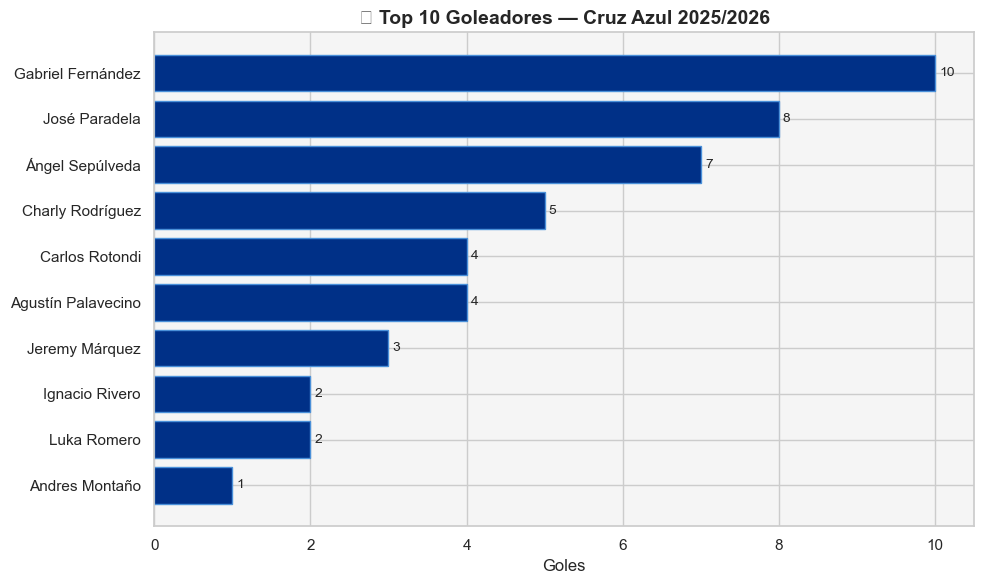

✅ Guardada: top_goleadores.png


In [8]:
AZUL       = '#003087'
AZUL_CLARO = '#4A90D9'
GRIS       = '#F5F5F5'
sns.set_theme(style='whitegrid')

top_goles = df_jugadores[['Player','Gls']].sort_values('Gls', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_goles['Player'], top_goles['Gls'], color=AZUL, edgecolor=AZUL_CLARO)
ax.invert_yaxis()
ax.set_xlabel('Goles', fontsize=12)
ax.set_title('⚽ Top 10 Goleadores — Cruz Azul 2025/2026', fontsize=14, fontweight='bold')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_facecolor(GRIS)
plt.tight_layout()
plt.savefig('top_goleadores.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardada: top_goleadores.png')

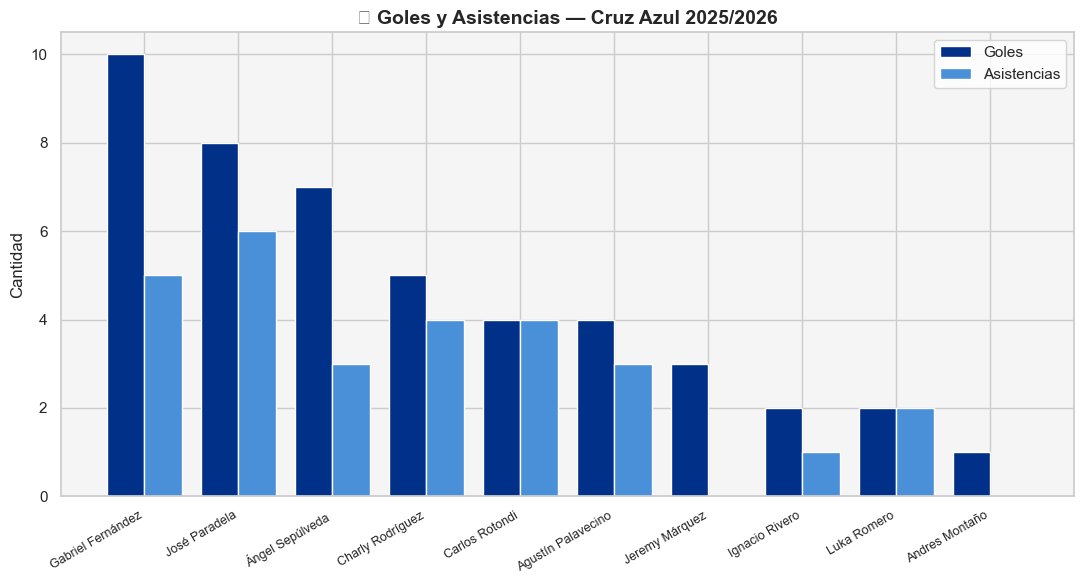

✅ Guardada: goles_asistencias.png


In [9]:
top_ga = df_jugadores[['Player','Gls','Ast']].sort_values('Gls', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
x     = range(len(top_ga))
width = 0.4

ax.bar([i - width/2 for i in x], top_ga['Gls'], width, label='Goles',       color=AZUL)
ax.bar([i + width/2 for i in x], top_ga['Ast'], width, label='Asistencias',  color=AZUL_CLARO)

ax.set_xticks(list(x))
ax.set_xticklabels(top_ga['Player'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Cantidad', fontsize=12)
ax.set_title('⚽ Goles y Asistencias — Cruz Azul 2025/2026', fontsize=14, fontweight='bold')
ax.legend()
ax.set_facecolor(GRIS)
plt.tight_layout()
plt.savefig('goles_asistencias.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardada: goles_asistencias.png')

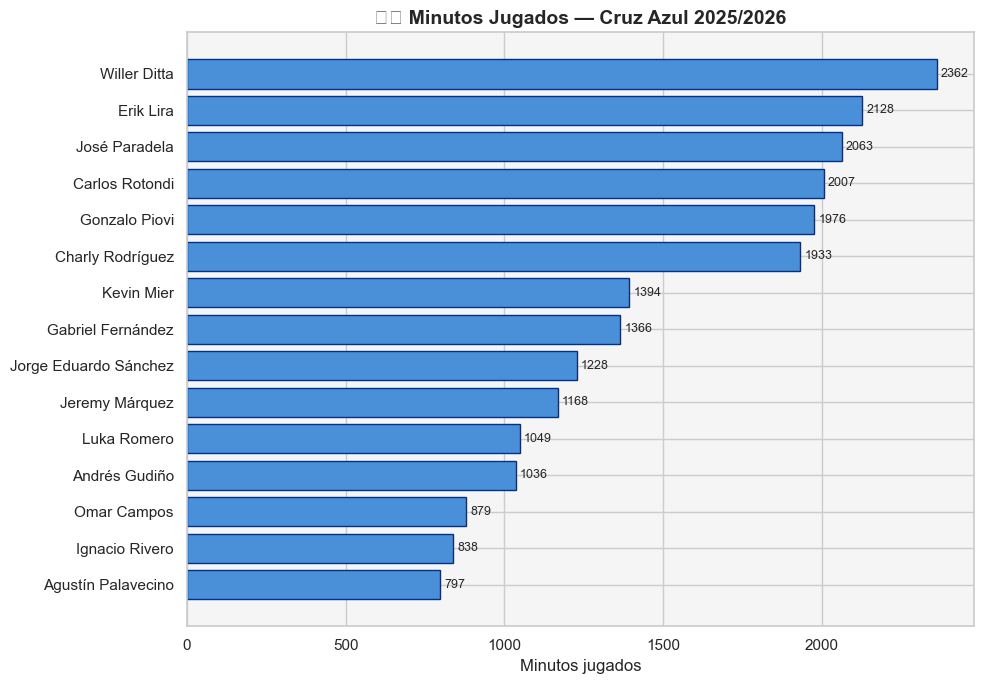

✅ Guardada: minutos_jugados.png


In [10]:
top_min = df_jugadores[['Player','Min']].sort_values('Min', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_min['Player'], top_min['Min'], color=AZUL_CLARO, edgecolor=AZUL)
ax.invert_yaxis()
ax.set_xlabel('Minutos jugados', fontsize=12)
ax.set_title('⏱️ Minutos Jugados — Cruz Azul 2025/2026', fontsize=14, fontweight='bold')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_facecolor(GRIS)
plt.tight_layout()
plt.savefig('minutos_jugados.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardada: minutos_jugados.png')